# Heart Disease Dataset Creation

This notebook combines three heart disease datasets into one dataset with the best features.

**Process of secetion:**
1. Load and fix 3 datasets (heart_1, heart_2, heart_3)
2. Will extract selected columns
3. Fix missing cholesterol values (replace 0 with average)
4. Select best 918 rows (least missing values)
5. Save to main_dataset.csv

## 1. Import Libraries

In [305]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


print("=" * 70)
print("CREATING main_dataset.csv")
print("=" * 70)

CREATING main_dataset.csv


## 2.  Selected Columns

These 9 features were selected:
- **cp**: Chest pain type
- **thalach**: Maximum heart rate
- **oldpeak**: ST depression
- **exang**: Exercise induced angina
- **chol**: Cholesterol
- **slope**: ST slope
- **age**: Age
- **sex**: Sex
- **target**: Heart disease (0=No, 1=Yes) 

////////////////////////////////////////////////////////////////////////////////////////

- cp: Different pain types indicate different conditions
- thalach: Lower max heart rate = potential disease
- oldpeak: ECG measurement of heart electrical activity
- exang: Pain during exercise = major warning sign
- chol: Blocks arteries but not the strongest predictor
- slope: ECG curve shape during exercise
- age: Risk increases with age
- sex: Men have higher risk
- target: What we're predicting

**Top 4 (Exercise Test Results):**
1. cp - Pain type during/after exercise
2. thalach - Max heart rate during exercise
3. oldpeak - ST depression during exercise
4. exang - Chest pain during exercise

These 4 together paint a complete picture of how the heart performs under stress

**Supporting Factors:**
5. chol - Long-term artery health
6. slope - Heart electrical recovery
7. age - Time for disease to develop
8. sex - Baseline risk level

In [306]:
# columns for the final dataset
SELECTED_COLUMNS = ['cp', 'thalach', 'oldpeak', 'exang', 'chol', 'slope', 'age', 'sex', 'target']

## 3. Process heart_1.csv

This dataset has different column names and categorical values that need conversion.

In [307]:
# 1. Process heart_1.csv
df1 = pd.read_csv('heart_1.csv')

print("Creating the dataset main_dataset.csv")

# Rename columns
df1 = df1.rename(columns={
    'Age': 'age',
    'Sex': 'sex',
    'ChestPainType': 'cp',
    'MaxHR': 'thalach',
    'Oldpeak': 'oldpeak',
    'ExerciseAngina': 'exang',
    'Cholesterol': 'chol',
    'ST_Slope': 'slope',
    'HeartDisease': 'target'
})

# Convert categorical to numeric
df1['sex'] = df1['sex'].map({'M': 1, 'F': 0})
df1['cp'] = df1['cp'].map({'TA': 1, 'ATA': 2, 'NAP': 3, 'ASY': 4}) # TA = Typical Angina, ATA = Atypical Angina, NAP = Non-Anginal Pain, ASY = Asymptomatic
df1['exang'] = df1['exang'].map({'N': 0, 'Y': 1})
df1['slope'] = df1['slope'].map({'Up': 1, 'Flat': 2, 'Down': 3}) # Upsloping (value: 1) - healthy,  Flat (value: 2) - concerning, Downsloping (value: 3) - dangerous

# Keep only selected columns
df1 = df1[SELECTED_COLUMNS]
print(f"   Extracted {len(df1)} rows")

# Display first few rows(5)
df1.head()

Creating the dataset main_dataset.csv
   Extracted 918 rows


,cp,thalach,oldpeak,exang,chol,slope,age,sex,target
0,2,172,0.0,0,289,1,40,1,0
1,3,156,1.0,0,180,2,49,0,1
2,2,98,0.0,0,283,1,37,1,0
3,4,108,1.5,1,214,2,48,0,1
4,3,122,0.0,0,195,1,54,1,0


## 4. Process heart_2.csv

This dataset already has numeric values and standard column names.

In [308]:
df2 = pd.read_csv('heart_2.csv')

# Rename target column
df2 = df2.rename(columns={'target_binary': 'target'})

# Keep only selected columns
df2 = df2[SELECTED_COLUMNS]
print(f"   Extracted {len(df2)} rows")

# Display first few rows
df2.head()

   Extracted 1024 rows


,cp,thalach,oldpeak,exang,chol,slope,age,sex,target
0,1,150.0,2.3,0,233.0,3,63.0,1,0
1,4,108.0,1.5,1,286.0,2,67.0,1,1
2,4,129.0,2.6,1,229.0,2,67.0,1,1
3,3,187.0,3.5,0,250.0,3,37.0,1,0
4,2,172.0,1.4,0,204.0,1,41.0,0,0


## 5. Process heart_3.csv

This dataset has different categorical formats and a multi-class target that needs conversion.

In [309]:
# 3. Process heart_3.csv
df3 = pd.read_csv('heart_3.csv')

# Rename columns
df3 = df3.rename(columns={
    'thalch': 'thalach',
    'num': 'target'
})

# Convert categorical to numeric
df3['sex'] = df3['sex'].map({'Male': 1, 'Female': 0})
df3['cp'] = df3['cp'].map({
    'typical angina': 1,
    'atypical angina': 2,
    'non-anginal pain': 3,
    'asymptomatic': 4
})
df3['exang'] = df3['exang'].map({True: 1, False: 0})
df3['slope'] = df3['slope'].map({
    'upsloping': 1,
    'flat': 2,
    'downsloping': 3
})

# Convert target to binary (0-4 scale to 0-1)
df3['target'] = (df3['target'] > 0).astype(int)

# Keep only selected columns
df3 = df3[SELECTED_COLUMNS]
print(f"   Extracted {len(df3)} rows")

# Display first few rows

df3.head()

   Extracted 920 rows


,cp,thalach,oldpeak,exang,chol,slope,age,sex,target
0,1.0,150.0,2.3,0.0,233.0,3.0,63,1,0
1,4.0,108.0,1.5,1.0,286.0,2.0,67,1,1
2,4.0,129.0,2.6,1.0,229.0,2.0,67,1,1
3,NaN,187.0,3.5,0.0,250.0,3.0,37,1,0
4,2.0,172.0,1.4,0.0,204.0,1.0,41,0,0


## 6. Combine All Datasets

Stack all three datasets on top of each other.

In [310]:
# Concatenate all three
combined = pd.concat([df1, df2, df3], ignore_index=True)
print(f"   Total rows: {len(combined)}")

   Total rows: 2862


## 7. Fix Cholesterol Values

Replace 0 cholesterol values (medically impossible) with the average.

In [311]:
# 5. Fix cholesterol: Replace 0 with average
# Count zeros in cholesterol
zero_count = (combined['chol'] == 0).sum()
print(f"   Found {zero_count} rows with cholesterol = 0")

if zero_count > 0:
    # Calculate average cholesterol (excluding zeros)
    avg_chol = combined[combined['chol'] > 0]['chol'].mean()
    print(f"   Average cholesterol (excluding 0s): {avg_chol:.1f} mg/dl")
    
    # Replace 0 with average
    combined.loc[combined['chol'] == 0, 'chol'] = round(avg_chol, 1)
    print(f"   ✓ Replaced {zero_count} zero values with {avg_chol:.1f}")
else:
    print("   ✓ No zero values found in cholesterol")

# Verification no more zeros
print(f"\nVerification: Cholesterol zeros remaining: {(combined['chol'] == 0).sum()}")

   Found 344 rows with cholesterol = 0
   Average cholesterol (excluding 0s): 246.2 mg/dl
   ✓ Replaced 344 zero values with 246.2

Verification: Cholesterol zeros remaining: 0


## 8. Select Best Quality Rows

Select 918 rows with the least missing values.

In [312]:
# Select best rows (least missing values)
combined['missing_count'] = combined.isna().sum(axis=1)
combined = combined.sort_values('missing_count')

# Take top 918 rows with least missing values
final_dataset = combined.head(918).drop('missing_count', axis=1)

print(f"Selected {len(final_dataset)} best quality rows")
print(f"Missing values per column:")
print(final_dataset.isna().sum())

Selected 918 best quality rows
Missing values per column:
cp         0
thalach    0
oldpeak    0
exang      0
chol       0
slope      0
age        0
sex        0
target     0
dtype: int64


## 9. Shuffle Dataset

Randomly shuffle rows for better machine learning performance.

In [313]:
# Shuffle the dataset
final_dataset = final_dataset.sample(frac=1, random_state=333).reset_index(drop=True)

print("Dataset shuffled with random_state=33(reproducible)")
final_dataset.head(10)

Dataset shuffled with random_state=33(reproducible)


,cp,thalach,oldpeak,exang,chol,slope,age,sex,target
0,2.0,140.0,0.0,0.0,166.0,1.0,56.0,1,0
1,2.0,150.0,0.0,0.0,220.0,1.0,34.0,1,0
2,2.0,124.0,1.0,0.0,188.0,2.0,59.0,0,0
3,2.0,160.0,0.0,0.0,344.0,1.0,55.0,0,0
4,4.0,108.0,1.5,1.0,286.0,2.0,67.0,1,1
5,1.0,190.0,0.0,0.0,186.0,2.0,52.0,1,0
6,4.0,182.0,0.0,0.0,271.0,1.0,59.0,1,0
7,4.0,138.0,0.5,0.0,246.2,1.0,58.0,1,1
8,4.0,140.0,1.0,1.0,246.2,2.0,64.0,0,1
9,4.0,126.0,1.2,1.0,282.0,2.0,56.0,1,1


## 10. Save to CSV

In [314]:
# Save to CSV
final_dataset.to_csv('main_dataset.csv', index=False)
print("✓ Saved to main_dataset.csv")

✓ Saved to main_dataset.csv


## 11. Summary Statistics

In [315]:
# Summary
print("\n" + "=" * 70)
print("✅ SUCCESS!")
print("=" * 70)
print(f"\nCreated: main_dataset.csv")
print(f"Rows: {len(final_dataset)}")
print(f"Columns: {len(final_dataset.columns)}")
print(f"\nColumns included:")
for i, col in enumerate(final_dataset.columns, 1):
    print(f"  {i}. {col}")

print(f"\nTarget distribution:")
print(f"  No disease (0): {(final_dataset['target'] == 0).sum()}")
print(f"  Has disease (1): {(final_dataset['target'] == 1).sum()}")

print("\n" + "=" * 70)


✅ SUCCESS!

Created: main_dataset.csv
Rows: 918
Columns: 9

Columns included:
  1. cp
  2. thalach
  3. oldpeak
  4. exang
  5. chol
  6. slope
  7. age
  8. sex
  9. target

Target distribution:
  No disease (0): 406
  Has disease (1): 512



## 12. Display Data

In [316]:
data = pd.read_csv("main_dataset.csv")

print("Descriptive statistics:")
display(data.describe())

Descriptive statistics:


,cp,thalach,oldpeak,exang,chol,slope,age,sex,target
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,3.255991,136.928105,0.915795,0.407407,245.114815,1.649237,53.733115,0.791939,0.557734
std,0.935687,25.546230,1.077641,0.491620,53.260891,0.613422,9.404610,0.406142,0.496926
min,1.000000,60.000000,-2.600000,0.000000,85.000000,1.000000,28.000000,0.000000,0.000000
25%,3.000000,120.000000,0.000000,0.000000,214.000000,1.000000,47.000000,1.000000,0.000000
50%,4.000000,138.000000,0.600000,0.000000,246.200000,2.000000,54.500000,1.000000,1.000000
75%,4.000000,156.000000,1.575000,1.000000,267.000000,2.000000,60.000000,1.000000,1.000000
max,4.000000,202.000000,6.200000,1.000000,603.000000,3.000000,77.000000,1.000000,1.000000


In [317]:
print("First 10 rows:")
display(data.head(10))

First 10 rows:


,cp,thalach,oldpeak,exang,chol,slope,age,sex,target
0,2.0,140.0,0.0,0.0,166.0,1.0,56.0,1,0
1,2.0,150.0,0.0,0.0,220.0,1.0,34.0,1,0
2,2.0,124.0,1.0,0.0,188.0,2.0,59.0,0,0
3,2.0,160.0,0.0,0.0,344.0,1.0,55.0,0,0
4,4.0,108.0,1.5,1.0,286.0,2.0,67.0,1,1
5,1.0,190.0,0.0,0.0,186.0,2.0,52.0,1,0
6,4.0,182.0,0.0,0.0,271.0,1.0,59.0,1,0
7,4.0,138.0,0.5,0.0,246.2,1.0,58.0,1,1
8,4.0,140.0,1.0,1.0,246.2,2.0,64.0,0,1
9,4.0,126.0,1.2,1.0,282.0,2.0,56.0,1,1


In [320]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)


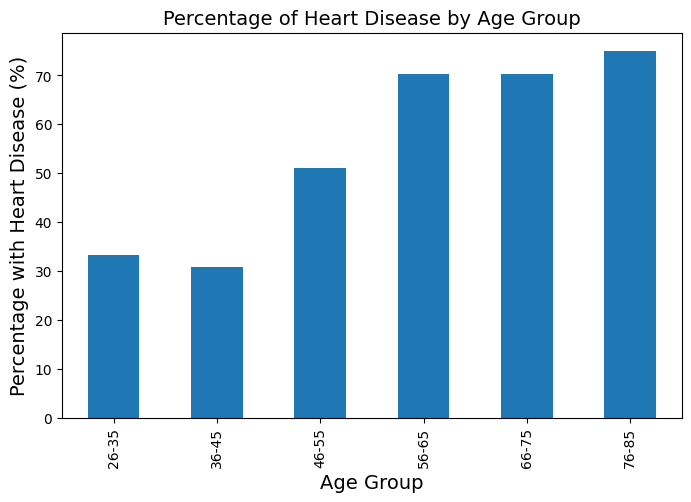

In [ ]:
# Create age groups
data["age_group"] = pd.cut(data["age"],bins=[25,35,45,55,65,75,85],labels=["26-35","36-45","46-55","56-65","66-75","76-85"])

age_disease = data.groupby("age_group")["target"].mean() * 100


plt.figure(figsize=(8,5))
age_disease.plot(kind="bar")

plt.title("Percentage of Heart Disease by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage with Heart Disease (%)")

plt.show()


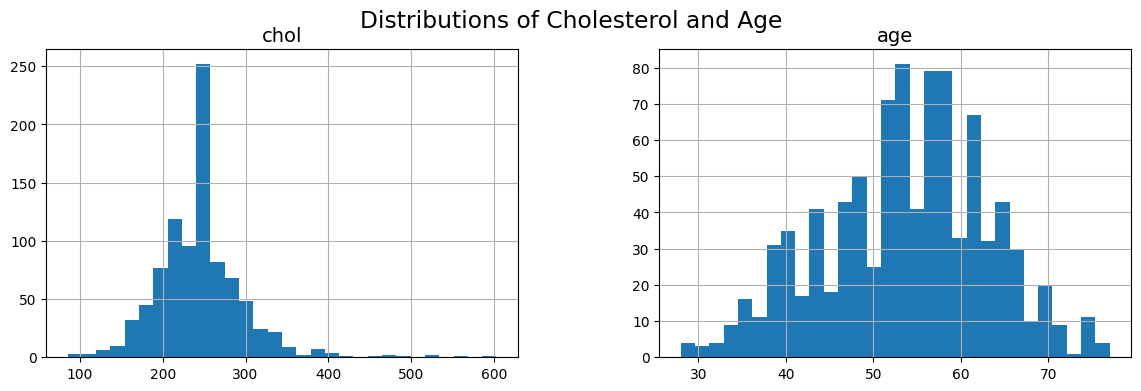

In [322]:
cols = ["chol", "age"]
data[cols].hist(bins=30, figsize=(14, 4))
plt.suptitle("Distributions of Cholesterol and Age")
plt.show()

The cholesterol distribution is right skewed, with most values concentrated between 200 and 300 and a small number of high value outliers.
The age distribution shows that most patients fall between 45 and 65 years, which aligns with typical heart disease risk profiles.
Both features show realistic patterns and no major data quality issues, making them suitable for model training after feature scaling.

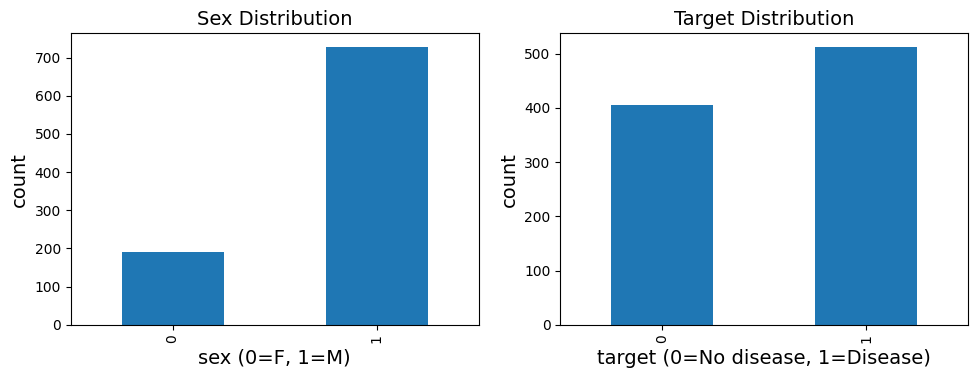

In [323]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

data["sex"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Sex Distribution")
axes[0].set_xlabel("sex (0=F, 1=M)")
axes[0].set_ylabel("count")

data["target"].value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Target Distribution")
axes[1].set_xlabel("target (0=No disease, 1=Disease)")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()



These bar charts show the distribution of sex and the target variable in the dataset.
There are more male patients than female patients, which reflects known trends in heart disease prevalence.
The target variable is reasonably balanced, with a slightly higher number of patients diagnosed with heart disease.
This balance is beneficial for supervised learning and helps reduce bias during model training.

Overall, these visualisations show that the data looks realistic and is suitable for training our machine learning models.

## Dataset Creation Complete!

`main_dataset.csv` is ready !

